In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import itertools
import csv

ruta_datos = "/Users/jose/Desktop/GameTheory_project/filtered_gene_bc_matrices/hg19/"

adata = sc.read_10x_mtx(ruta_datos, var_names='gene_symbols')

print(adata)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'


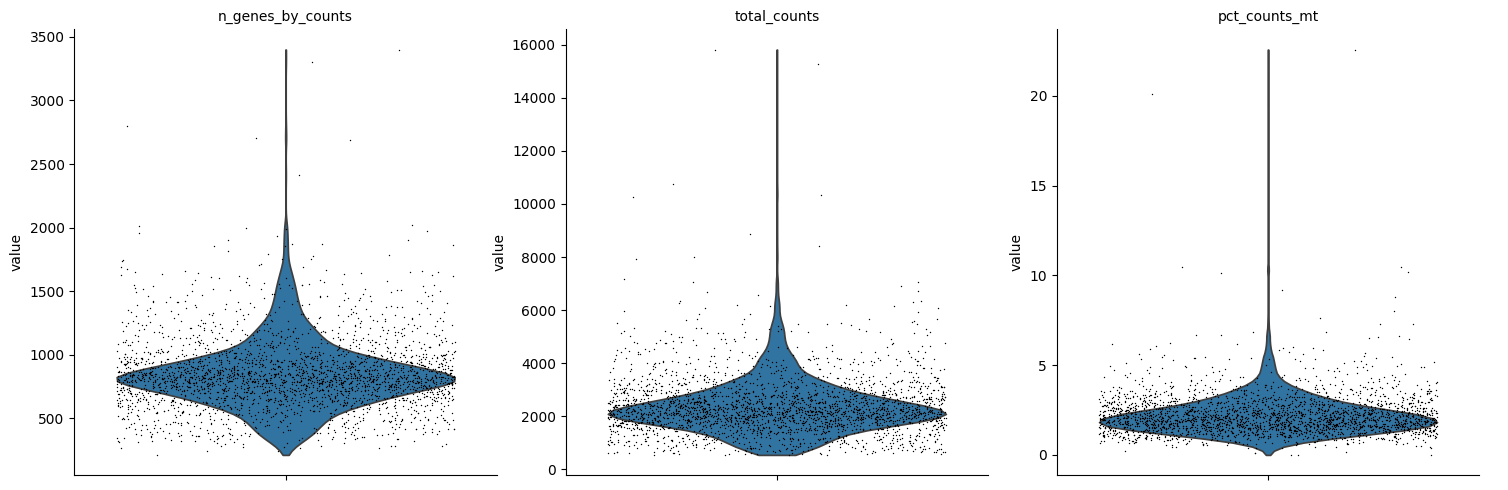

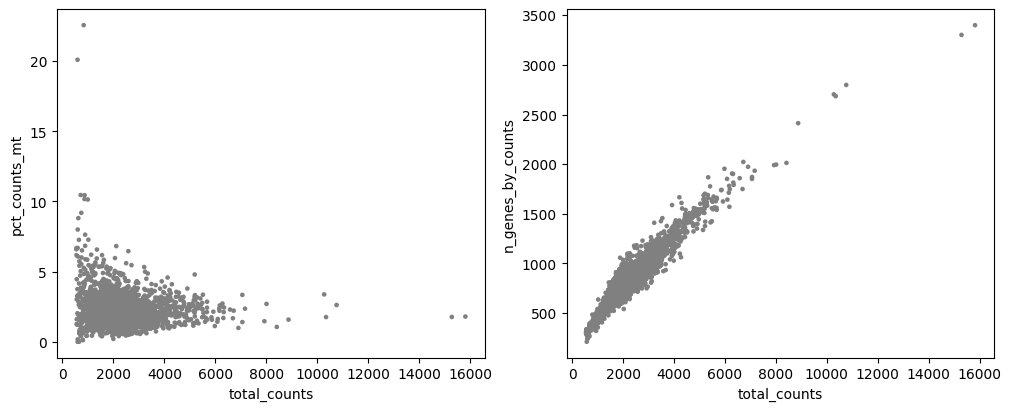

In [2]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1]);

adata = adata[
    (adata.obs.n_genes_by_counts < 2500)
    & (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'


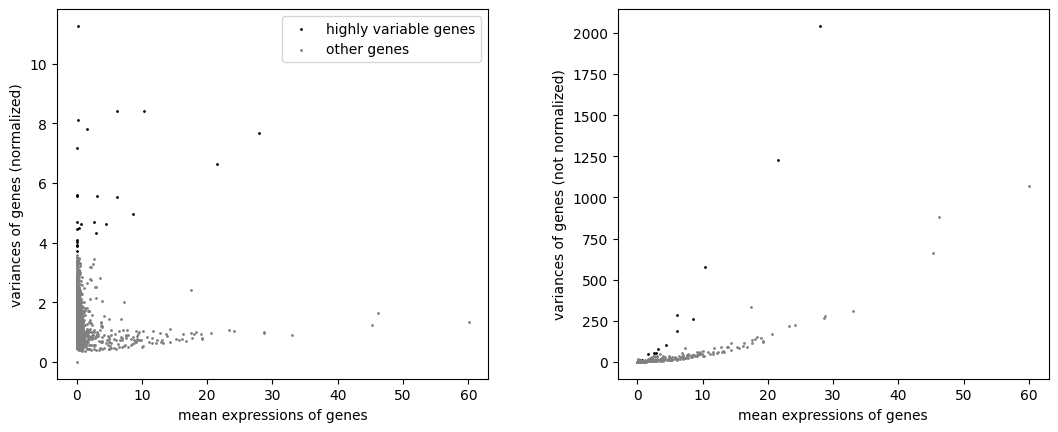

AL627309.1       False
AP006222.2       False
RP11-206L10.2    False
RP11-206L10.9    False
LINC00115        False
                 ...  
AC145212.1       False
AL592183.1       False
AL354822.1       False
PNRC2-1          False
SRSF10-1         False
Name: highly_variable, Length: 13714, dtype: bool
['C1QA', 'C1QB', 'S100A9', 'S100A8', 'FCER1A', 'GNLY', 'SDPR', 'PF4', 'PPBP', 'CD74', 'HLA-DRA', 'HLA-DPB1', 'GUSB', 'GNG11', 'CLU', 'FTH1', 'LYZ', 'GZMB', 'AL928768.3', 'CCL4', 'CST3', 'TUBB1', 'FTL', 'NKG7', 'IGLL5']


In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

print(adata)

sc.pp.highly_variable_genes(adata,layer="counts",n_top_genes=25,min_mean=0.0125,max_mean=3,min_disp=0.5,flavor="seurat_v3")

sc.pl.highly_variable_genes(adata)

print(adata.var['highly_variable'])

genes_mas_variables = adata.var[adata.var['highly_variable']]

indices_genes_mas_variables = np.where(adata.var['highly_variable'])[0]

#Guardar genes mas variables
genes_mas_variables.to_csv("/Users/jose/Desktop/GameTheory_project/genes_mas_variables.csv")
np.savetxt("/Users/jose/Desktop/GameTheory_project/indices_genes_mas_variables.csv", indices_genes_mas_variables, delimiter=",")

genes_mas_variables_array = np.array(genes_mas_variables)

nombres_genes_mas_variables = adata.var[adata.var['highly_variable']].index.tolist()

print(nombres_genes_mas_variables)

In [4]:
# Print variance values used by highly_variable_genes (normalized metrics)
print("=== VARIANCE METRICS FROM highly_variable_genes (normalized) ===\n")

# Inspect columns added by HVG to locate variance-related fields
cols = adata.var.columns.tolist()
keep_cols = [c for c in cols if any(k in c.lower() for k in ["highly_variable","mean","variance","dispersion","nbatches","intersection"]) ]
print("Columns in adata.var related to HVG:")
print(keep_cols)
print()

# Subset to highly variable genes
hvg_mask = adata.var["highly_variable"].values if "highly_variable" in adata.var.columns else None
if hvg_mask is None:
    raise RuntimeError("highly_variable_genes has not been computed (column 'highly_variable' not found in adata.var)")

hvg_var = adata.var.loc[hvg_mask].copy()
indices_hvg = np.where(hvg_mask)[0]  # índices posicionales en adata.var

# Build a tidy dataframe with all available metrics
out = {
    "gene": hvg_var.index.to_list(),
    "index": indices_hvg.tolist()
}
for col in ["means","variances","variances_norm","dispersions","dispersions_norm","highly_variable_nbatches","highly_variable_intersection"]:
    if col in hvg_var.columns:
        out[col] = hvg_var[col].to_list()

import pandas as pd
hvg_df = pd.DataFrame(out)

# Pretty print a compact preview
print("Top 15 HVG metrics (head):")
print(hvg_df.head(25))

# Imprimir índices y genes
print("\nÍndices y genes altamente variables:")
for g, idx in zip(hvg_df["gene"], hvg_df["index"]):
    print(f"  {idx}: {g}")

# Print only the variance columns explicitly if present
if "variances" in hvg_df.columns:
    print("\nRaw variance (variances) for HVGs:")
    for g, v, idx in zip(hvg_df["gene"], hvg_df["variances"], hvg_df["index"]):
        print(f"  {idx} | {g}: {v:.6f}")

if "variances_norm" in hvg_df.columns:
    print("\nNormalized variance (variances_norm) for HVGs:")
    for g, v, idx in zip(hvg_df["gene"], hvg_df["variances_norm"], hvg_df["index"]):
        print(f"  {idx} | {g}: {v:.6f}")

# Optional: save to CSV for downstream analysis (incluye índice)
csv_out = "/Users/jose/Desktop/GameTheory_project/hvg_variance_metrics_with_indices_main_v3.csv"
hvg_df.to_csv(csv_out, index=False)
print(f"\nSaved HVG variance metrics (with indices) to: {csv_out}")

=== VARIANCE METRICS FROM highly_variable_genes (normalized) ===

Columns in adata.var related to HVG:
['mean_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm']

Top 15 HVG metrics (head):
          gene  index      means    variances  variances_norm
0         C1QA    213   0.043215     0.339429        4.459221
1         C1QB    215   0.028810     0.269932        4.018014
2       S100A9    907   6.146323   284.275131        8.418021
3       S100A8    909   3.174754    79.338050        5.580462
4       FCER1A   1012   0.112585     1.970255        5.559217
5         GNLY   1803   1.599318    46.202305        7.829945
6         SDPR   2129   0.069371     1.294010        4.090622
7          PF4   3314   0.111827     2.782712        7.184976
8         PPBP   3315   0.248673     9.795552       11.272186
9         CD74   4025   8.579606   261.893357        4.973804
10     HLA-DRA   4409   6.151251   186.795089        5.525553
11    HLA-DPB1   4429   2.

Guardado: /Users/jose/Desktop/GameTheory_project/violin_genes_1_20260330_195714.pdf


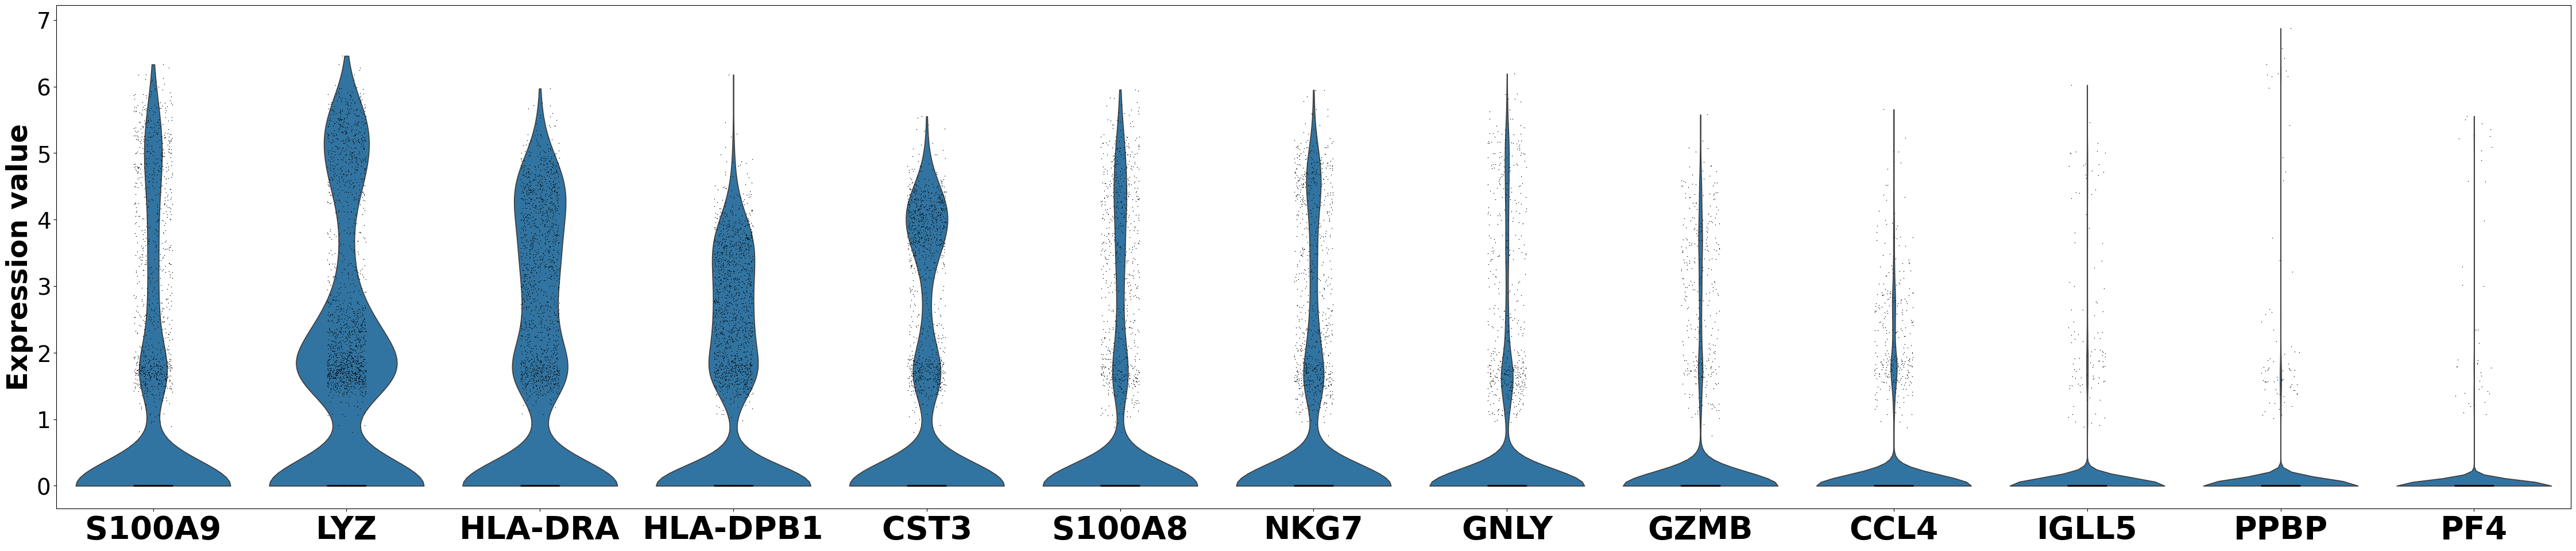

Guardado: /Users/jose/Desktop/GameTheory_project/violin_genes_2_20260330_195714.pdf


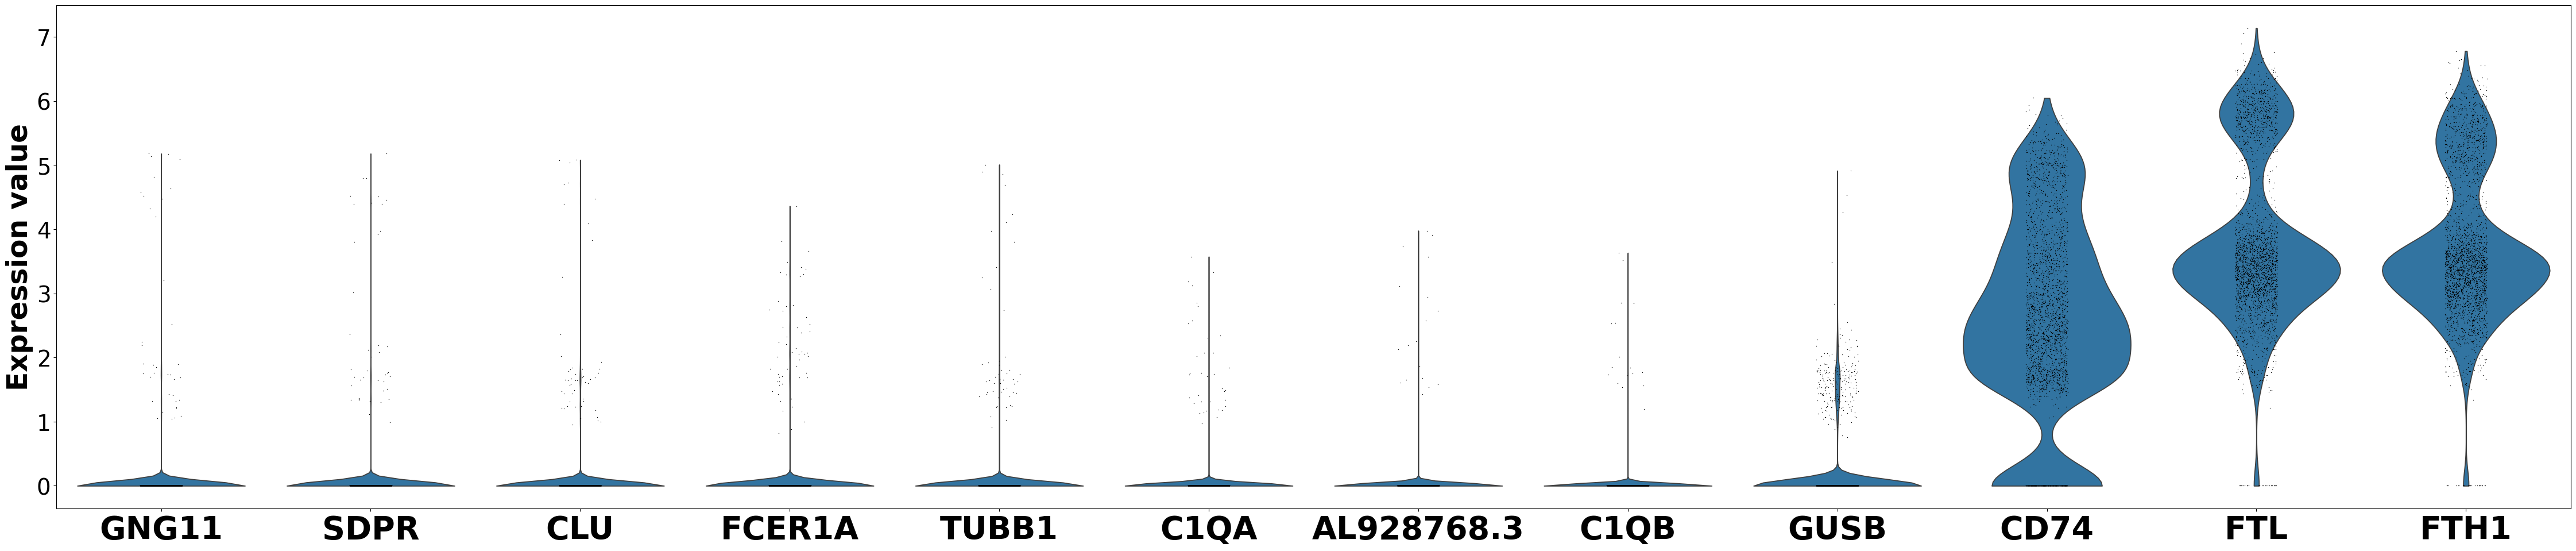

In [5]:
from datetime import datetime

genes_1 = ['S100A9','LYZ','HLA-DRA','HLA-DPB1','CST3',
            'S100A8','NKG7','GNLY','GZMB','CCL4',
            'IGLL5','PPBP','PF4']

genes_2=['GNG11','SDPR',
            'CLU','FCER1A','TUBB1','C1QA','AL928768.3',
            'C1QB','GUSB','CD74','FTL','FTH1']

# Primera tanda de violin plots
sc.pl.violin(
    adata,
    keys=genes_1,
    groupby=None,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(65, 12)

for ax in np.ravel(fig.axes):
    for label in ax.get_xticklabels():
        label.set_fontsize(40)
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontsize(28)
    ax.set_ylabel('Expression value', fontsize=35, fontweight='bold')

# Guardar PDF
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
pdf_path_1 = f"/Users/jose/Desktop/GameTheory_project/violin_genes_1_{_ts}.pdf"
fig.savefig(pdf_path_1, bbox_inches='tight')
print(f"Guardado: {pdf_path_1}")

plt.show()

# Segunda tanda de violin plots
sc.pl.violin(
    adata,
    keys=genes_2,
    groupby=None,
    show=False
)
fig2 = plt.gcf()
fig2.set_size_inches(65, 12)

for ax in np.ravel(fig2.axes):
    for label in ax.get_xticklabels():
        label.set_fontsize(40)
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontsize(28)
    ax.set_ylabel('Expression value', fontsize=35, fontweight='bold')

# Guardar PDF segunda figura
pdf_path_2 = f"/Users/jose/Desktop/GameTheory_project/violin_genes_2_{_ts}.pdf"
fig2.savefig(pdf_path_2, bbox_inches='tight')
print(f"Guardado: {pdf_path_2}")

plt.show()
